In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import rc

_dpi = 100


def colormap(num_colors, name = 'rainbow') :
    cmap = mpl.cm.get_cmap(name = name, lut = num_colors)
    return cmap(range(num_colors))

#(10,10), size = 25

rc('text', usetex=True)
rc('font', family='serif', size = 15)

In [2]:
_R = 8.314 #J/mol/K

_rmin = 3.2
_rmax = 8
_nr = 100

r = np.linspace(_rmin, _rmax, _nr)  

def get_Ep(r, eps = 1, sig = 1) :
    return 4*eps*((sig/r)**12 - (sig/r)**6)

def get_sol(a) : 
    if a > -1 and a < 0 : 
        return (2 / a * (np.sqrt(1 + a) - 1))**(1/6), (-(2 / a * (np.sqrt(1 + a) + 1)))**(1/6)
    elif a == 0 : 
        return 1 , ax.get_xlim()[-1]
    else : 
        return (2 / a * (np.sqrt(1 + a) - 1))**(1/6), ax.get_xlim()[-1]


In [3]:
a = -0.8

(-(2 / a * (np.sqrt(1 + a) + 1)))**(1/6)

1.2390213038371403

[]


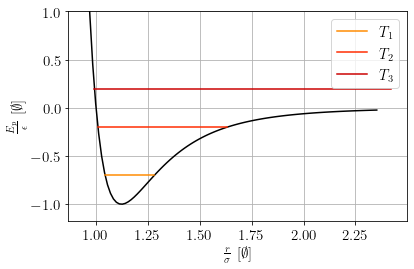

In [11]:
#LJ parameters
sig = 3.4 #angstrom
eps = 120 #Kelvin

#Kinetic energy
a = (-0.7, -0.2, 0.2)
colors = np.flip(colormap(len(a)+5, name = 'hot'), axis = 0)[3:-2]

ylim = (None, 1)

print(colors[5:])


r_norm = r/sig
Ep = get_Ep(r_norm, eps = 1, sig = 1)

#radius = 1/ (rho / M * Na)**(1/3) * 10**12

#radius = np.sqrt(3) / 4 * (2 * M / Na / rho)**(1/3)*10**11

#r_met = np.array([157, 191, 235, 250, 272])

fig = plt.figure(figsize=(6,4))
ax = fig.subplots()
#ax.plot(r_met, radius, marker = 'o', ls = 'none', markersize = 15, color = 'black', label = 'Points calculés')
#xlim= ax.get_xlim()
ax.plot(r_norm, Ep, color = 'black')

ax.set_xlabel("$\\frac{r}{\sigma}$ [$\emptyset$]")
ax.set_ylabel("$\\frac{E_p}{\epsilon}$ [$\emptyset$]")


for n in range(len(a)) : 
    xrange = get_sol(a[n])
    ax.plot(xrange, [a[n], a[n]], color = colors[n], label = "$T_{}$".format(n+1))
    
ax.grid()
ax.legend()

ax.set_ylim(*ylim)

fig.tight_layout()

fig.savefig("Gpy-01.pdf", dpi = _dpi)

On peut chercher les solutions au potentiel de Lennard Jones, tel que Ep = alpha
En posant la variable $X = x^6$, on trouve une condition nécessaire sur $X$ : 
$$\frac{\alpha}{4} X^2 + X -1 = 0$$

Ce polynôme a pour solution : 

$$X_\pm = - \frac{2}{\alpha} \pm \frac{2}{\alpha} \sqrt{1 + \alpha}$$

On trouve alors : 

$$x_- =  (\frac{2}{\alpha} \sqrt{1 + \alpha} - \frac{2}{\alpha})^{1/6}$$
$$x_+ =  (-\frac{2}{\alpha} \sqrt{1 + \alpha} - \frac{2}{\alpha})^{1/6}$$